# train_enhance_v1 — Diagnostics and improvements

What we do:
1. **Diagnostics** — class distribution, rare classes, per-class F1 of the baseline
2. **Fix 1** — LinearSVC (fixes SGD ConvergenceWarning)
3. **Fix 2** — word + char union features
4. **Fix 3** — merging rare classes into `unknown`
5. **Comparison** — summary table of all experiments

Issues from v2:
- SGD does not converge (ConvergenceWarning)
- Regions l1: 24 classes, Macro-F1 test = 0.393
- Regions l2: 167 classes, Macro-F1 test = 0.332
- Macro/Weighted gap ~0.5 → tail classes are not learned

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import FeatureUnion
from sklearn.metrics import f1_score, accuracy_score, classification_report

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)
rand_seed = 44

In [12]:
base = Path(r'C:/Users/artem/MAIN/projects/plain/local/python_modules/scripts/geo')
msk_path     = base / 'labeled_msk_df.csv'
regions_path = base / 'labeled_regions_df_v6.csv'

test_size = 0.2
val_size  = 0.1

# Classes with count < threshold will be merged into 'unknown'
RARE_THRESHOLD = 100

In [13]:
def load_df(path: Path):
    usecols = ['Source_File', 'Layer', 'Type', 'Text', 'l1', 'l2']
    df = pd.read_csv(path, usecols=usecols, low_memory=False)
    for col in ['Source_File', 'Layer', 'Type', 'Text']:
        df[col] = df[col].fillna('').astype(str)
    print(f'Loaded {path.name}: {len(df):,} rows, {df["Source_File"].nunique()} files')
    return df

msk_df = load_df(msk_path)
reg_df = load_df(regions_path)

Loaded labeled_msk_df.csv: 180,953 rows, 370 files
Loaded labeled_regions_df_v6.csv: 3,069,680 rows, 146 files


## 1. Class distribution diagnostics


Moscow l1 — всего классов: 12, строк: 180,953
  Классов с < 100 примеров: 1
  Классов с < 10 примеров: 0


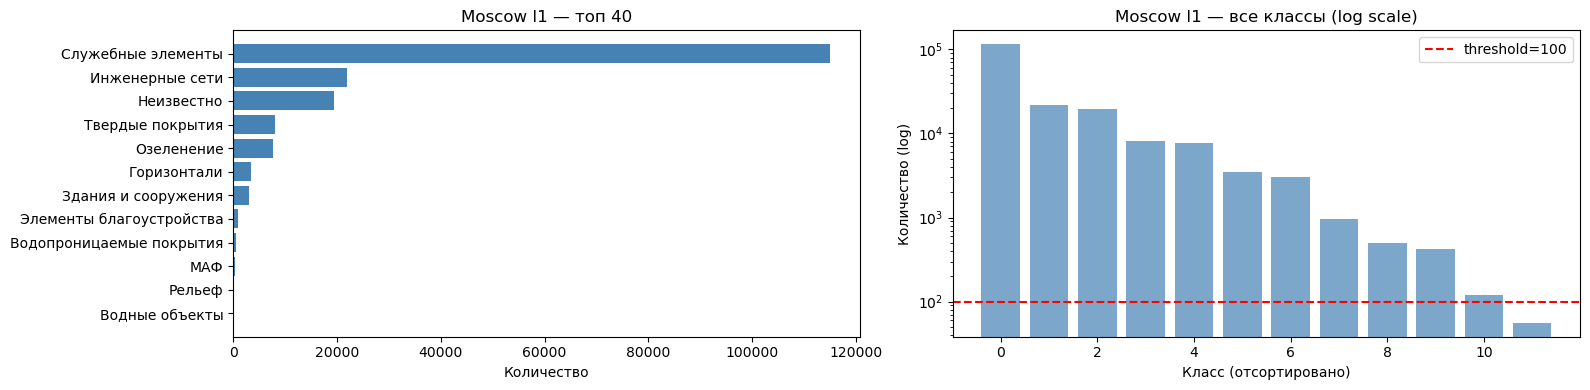


Moscow l2 — всего классов: 32, строк: 180,953
  Классов с < 100 примеров: 6
  Классов с < 10 примеров: 2


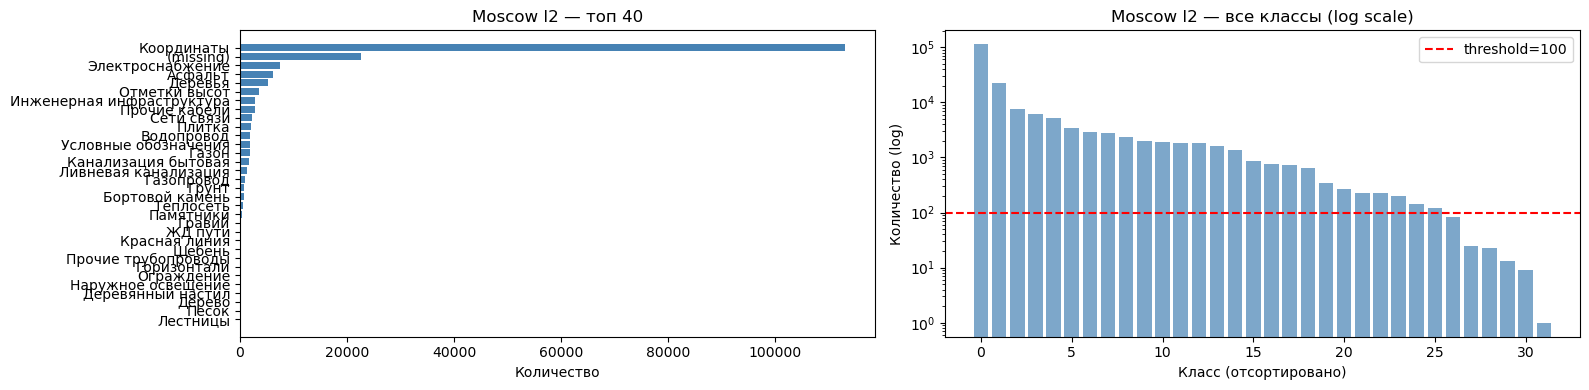

In [14]:
def plot_class_dist(df, col, title, top_n=40):
    counts = df[col].fillna('(missing)').value_counts()
    total  = len(df)
    print(f'\n{title} — total classes: {counts.shape[0]}, rows: {total:,}')
    print(f'  Classes with < {RARE_THRESHOLD} examples: {(counts < RARE_THRESHOLD).sum()}')
    print(f'  Classes with < 10 examples: {(counts < 10).sum()}')

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    # Top-N classes
    top = counts.head(top_n)
    axes[0].barh(top.index[::-1], top.values[::-1], color='steelblue')
    axes[0].set_title(f'{title} — top {top_n}')
    axes[0].set_xlabel('Count')

    # Log-scale tail
    axes[1].bar(range(len(counts)), sorted(counts.values, reverse=True), color='steelblue', alpha=0.7)
    axes[1].set_yscale('log')
    axes[1].axhline(RARE_THRESHOLD, color='red', linestyle='--', label=f'threshold={RARE_THRESHOLD}')
    axes[1].set_title(f'{title} — all classes (log scale)')
    axes[1].set_xlabel('Class (sorted)')
    axes[1].set_ylabel('Count (log)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    return counts

msk_l1_counts = plot_class_dist(msk_df, 'l1', 'Moscow l1')
msk_l2_counts = plot_class_dist(msk_df, 'l2', 'Moscow l2')


Regions l1 — всего классов: 11, строк: 3,069,680
  Классов с < 100 примеров: 0
  Классов с < 10 примеров: 0


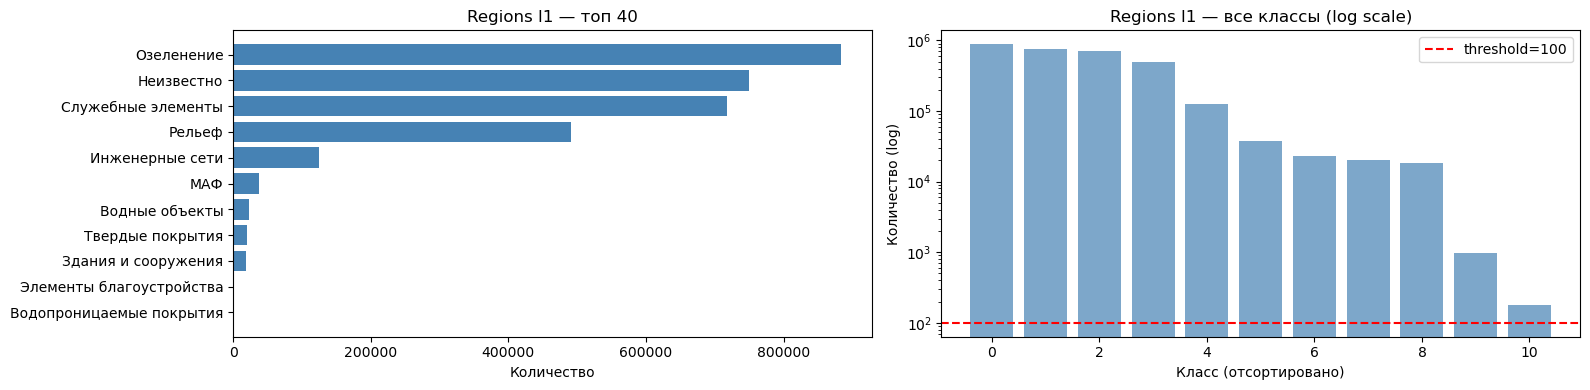


Regions l2 — всего классов: 41, строк: 3,069,680
  Классов с < 100 примеров: 3
  Классов с < 10 примеров: 0


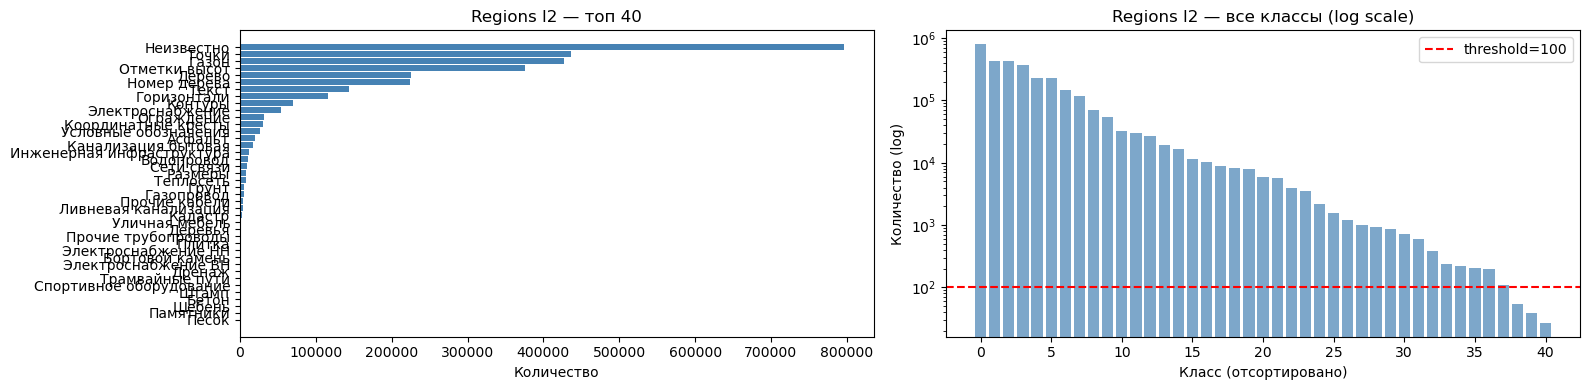

In [15]:
reg_l1_counts = plot_class_dist(reg_df, 'l1', 'Regions l1')
reg_l2_counts = plot_class_dist(reg_df, 'l2', 'Regions l2')

In [16]:
# Rare classes in Regions — inspect them
rare_l1 = reg_l1_counts[reg_l1_counts < RARE_THRESHOLD]
rare_l2 = reg_l2_counts[reg_l2_counts < RARE_THRESHOLD]

print('=== Rare classes l1 (Regions) ===')
print(rare_l1.to_string())
print(f'\n=== Rare classes l2 (Regions) — top-30 rarest ===')
print(rare_l2.tail(30).to_string())

=== Редкие классы l1 (Regions) ===
Series([], )

=== Редкие классы l2 (Regions) — топ-30 самых редких ===
Памятники            55
Песок                39
Деревянный настил    27


In [17]:
msk_df['l2'].unique()

array(['Красная линия', 'Координаты', 'Асфальт', nan, 'Деревья',
       'Инженерная инфраструктура', 'Отметки высот', 'Плитка', 'Гравий',
       'Бортовой камень', 'Газон', 'Условные обозначения', 'Щебень',
       'Памятники', 'Электроснабжение', 'Ливневая канализация',
       'Сети связи', 'Канализация бытовая', 'Водопровод', 'Прочие кабели',
       'Теплосеть', 'Газопровод', 'Песок', 'Наружное освещение',
       'Ограждение', 'Грунт', 'Прочие трубопроводы', 'Горизонтали',
       'Дерево', 'ЖД пути', 'Деревянный настил', 'Лестницы'], dtype=object)

In [18]:
reg_df['l1'].unique()

array(['Неизвестно', 'Служебные элементы', 'Озеленение', 'Рельеф', 'МАФ',
       'Твердые покрытия', 'Здания и сооружения', 'Инженерные сети',
       'Водопроницаемые покрытия', 'Водные объекты',
       'Элементы благоустройства'], dtype=object)

In [19]:
# l1 class comparison: present in Regions but not in Moscow
msk_l1_set = set(msk_df['l1'].dropna().unique())
reg_l1_set = set(reg_df['l1'].dropna().unique())

print('Only in Regions l1:')
for c in sorted(reg_l1_set - msk_l1_set):
    print(f'  {c!r:40s}  n={reg_l1_counts.get(c, 0):,}')

print('\nOnly in Moscow l1:')
for c in sorted(msk_l1_set - reg_l1_set):
    print(f'  {c!r}')

Только в Regions l1:

Только в Moscow l1:
  'Горизонтали'


## 2. Helper functions

In [20]:
def build_text_features(df: pd.DataFrame) -> pd.Series:
    return (
        'TYPE='  + df['Type'].astype(str)  + ' ' +
        'LAYER=' + df['Layer'].astype(str) + ' ' +
        'TEXT='  + df['Text'].astype(str)
    )

def split_train_val_test(X, y, groups):
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=rand_seed)
    tv_idx, te_idx = next(gss.split(X, y, groups=groups))

    gss2 = GroupShuffleSplit(n_splits=1, test_size=val_size, random_state=rand_seed)
    tr_idx, va_idx = next(gss2.split(X.iloc[tv_idx], y.iloc[tv_idx], groups=groups.iloc[tv_idx]))

    return (
        X.iloc[tv_idx].iloc[tr_idx], y.iloc[tv_idx].iloc[tr_idx], groups.iloc[tv_idx].iloc[tr_idx],
        X.iloc[tv_idx].iloc[va_idx], y.iloc[tv_idx].iloc[va_idx], groups.iloc[tv_idx].iloc[va_idx],
        X.iloc[te_idx],              y.iloc[te_idx],              groups.iloc[te_idx],
    )

def eval_split(y_true, y_pred, split_name):
    macro    = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    acc      = accuracy_score(y_true, y_pred)
    print(f'  {split_name:<6} | Macro-F1: {macro:.4f} | Weighted-F1: {weighted:.4f} | Acc: {acc:.4f}')
    return macro, weighted, acc

def prepare_data(df, label_col, rare_threshold=None):
    """Prepare X, y. Optionally merge rare classes into 'unknown'."""
    y = df[label_col].fillna('').astype(str).str.strip()
    mask = y != ''
    df_clean = df[mask].copy()
    y_clean  = y[mask].copy()

    if rare_threshold is not None:
        counts = y_clean.value_counts()
        rare   = set(counts[counts < rare_threshold].index)
        n_rare = (y_clean.isin(rare)).sum()
        y_clean = y_clean.where(~y_clean.isin(rare), other='unknown')
        print(f'  Merged rare classes: {len(rare)} → unknown ({n_rare:,} rows)')

    print(f'  Classes: {y_clean.nunique()}, rows: {len(y_clean):,}')
    return build_text_features(df_clean), y_clean, df_clean['Source_File']

results_log = []   # accumulate all results for the summary table

def run_experiment(name, dataset_name, label_col, model_pipeline, df,
                   rare_threshold=None, show_report=False):
    print(f'\n==== {dataset_name} | {label_col} | {name} ====')
    X, y, groups = prepare_data(df, label_col, rare_threshold)

    X_tr, y_tr, g_tr, X_va, y_va, g_va, X_te, y_te, g_te = split_train_val_test(X, y, groups)
    print(f'  Train: {len(X_tr):,} | Val: {len(X_va):,} | Test: {len(X_te):,}')

    model_pipeline.fit(X_tr, y_tr)

    for split_X, split_y, split_name in [(X_tr, y_tr, 'train'), (X_va, y_va, 'val'), (X_te, y_te, 'test')]:
        pred = model_pipeline.predict(split_X)
        m, w, a = eval_split(split_y, pred, split_name)
        if split_name == 'test':
            results_log.append({
                'experiment': name, 'dataset': dataset_name,
                'label': label_col, 'macro_f1': m,
                'weighted_f1': w, 'accuracy': a,
                'classes': y.nunique(),
            })

    if show_report:
        pred_te = model_pipeline.predict(X_te)
        print(classification_report(y_te, pred_te, zero_division=0))

    return model_pipeline

## 3. SGD baseline — reproducing v2 for comparison

In [21]:
def make_sgd_baseline():
    return Pipeline([
        ('tfidf', TfidfVectorizer(
            analyzer='char_wb', ngram_range=(3, 5),
            min_df=2, max_features=200_000,
        )),
        ('clf', SGDClassifier(
            loss='log_loss', alpha=1e-5, max_iter=20, tol=1e-3,
            n_jobs=-1, random_state=rand_seed, class_weight='balanced',
        ))
    ])

run_experiment('SGD-baseline', 'Moscow',  'l1', make_sgd_baseline(), msk_df)
run_experiment('SGD-baseline', 'Moscow',  'l2', make_sgd_baseline(), msk_df)
run_experiment('SGD-baseline', 'Regions', 'l1', make_sgd_baseline(), reg_df)
run_experiment('SGD-baseline', 'Regions', 'l2', make_sgd_baseline(), reg_df)


==== Moscow | l1 | SGD-baseline ====
  Классов: 12, строк: 180,953
  Train: 104,953 | Val: 5,886 | Test: 70,114
  train  | Macro-F1: 0.9753 | Weighted-F1: 0.9977 | Acc: 0.9977
  val    | Macro-F1: 0.9008 | Weighted-F1: 0.9959 | Acc: 0.9958
  test   | Macro-F1: 0.9601 | Weighted-F1: 0.9916 | Acc: 0.9915

==== Moscow | l2 | SGD-baseline ====
  Классов: 31, строк: 158,402
  Train: 87,613 | Val: 4,807 | Test: 65,982
  train  | Macro-F1: 0.9711 | Weighted-F1: 0.9967 | Acc: 0.9966
  val    | Macro-F1: 0.9566 | Weighted-F1: 0.9972 | Acc: 0.9973
  test   | Macro-F1: 0.9186 | Weighted-F1: 0.9892 | Acc: 0.9888

==== Regions | l1 | SGD-baseline ====
  Классов: 11, строк: 3,069,680
  Train: 2,390,049 | Val: 108,645 | Test: 570,986
  train  | Macro-F1: 0.9588 | Weighted-F1: 0.9923 | Acc: 0.9922
  val    | Macro-F1: 0.8921 | Weighted-F1: 0.9514 | Acc: 0.9527
  test   | Macro-F1: 0.9681 | Weighted-F1: 0.9821 | Acc: 0.9822

==== Regions | l2 | SGD-baseline ====
  Классов: 41, строк: 3,069,680
  Train

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(analyzer='char_wb', max_features=200000,
                                 min_df=2, ngram_range=(3, 5))),
                ('clf',
                 SGDClassifier(alpha=1e-05, class_weight='balanced',
                               loss='log_loss', max_iter=20, n_jobs=-1,
                               random_state=44))])

## 4. Fix 1 — LinearSVC (fixes SGD convergence issue)

In [22]:
def make_linear_svc():
    return Pipeline([
        ('tfidf', TfidfVectorizer(
            analyzer='char_wb', ngram_range=(3, 5),
            min_df=2, max_features=200_000,
        )),
        ('clf', LinearSVC(
            C=0.5, max_iter=3000,
            class_weight='balanced',
        ))
    ])

run_experiment('LinearSVC', 'Moscow',  'l1', make_linear_svc(), msk_df)
run_experiment('LinearSVC', 'Moscow',  'l2', make_linear_svc(), msk_df)
run_experiment('LinearSVC', 'Regions', 'l1', make_linear_svc(), reg_df)
run_experiment('LinearSVC', 'Regions', 'l2', make_linear_svc(), reg_df)


==== Moscow | l1 | LinearSVC ====
  Классов: 12, строк: 180,953
  Train: 104,953 | Val: 5,886 | Test: 70,114


c:\ProgramData\anaconda3\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  train  | Macro-F1: 0.9977 | Weighted-F1: 0.9994 | Acc: 0.9994
  val    | Macro-F1: 0.9937 | Weighted-F1: 0.9973 | Acc: 0.9973
  test   | Macro-F1: 0.9851 | Weighted-F1: 0.9955 | Acc: 0.9954

==== Moscow | l2 | LinearSVC ====
  Классов: 31, строк: 158,402
  Train: 87,613 | Val: 4,807 | Test: 65,982
  train  | Macro-F1: 0.9940 | Weighted-F1: 0.9988 | Acc: 0.9988
  val    | Macro-F1: 0.9561 | Weighted-F1: 0.9970 | Acc: 0.9971
  test   | Macro-F1: 0.9234 | Weighted-F1: 0.9965 | Acc: 0.9964

==== Regions | l1 | LinearSVC ====
  Классов: 11, строк: 3,069,680
  Train: 2,390,049 | Val: 108,645 | Test: 570,986


c:\ProgramData\anaconda3\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  train  | Macro-F1: 0.9945 | Weighted-F1: 0.9978 | Acc: 0.9978
  val    | Macro-F1: 0.9125 | Weighted-F1: 0.9600 | Acc: 0.9613
  test   | Macro-F1: 0.9145 | Weighted-F1: 0.9899 | Acc: 0.9900

==== Regions | l2 | LinearSVC ====
  Классов: 41, строк: 3,069,680
  Train: 2,390,049 | Val: 108,645 | Test: 570,986


c:\ProgramData\anaconda3\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  train  | Macro-F1: 0.9890 | Weighted-F1: 0.9977 | Acc: 0.9976
  val    | Macro-F1: 0.9128 | Weighted-F1: 0.9623 | Acc: 0.9651
  test   | Macro-F1: 0.9607 | Weighted-F1: 0.9899 | Acc: 0.9902


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(analyzer='char_wb', max_features=200000,
                                 min_df=2, ngram_range=(3, 5))),
                ('clf',
                 LinearSVC(C=0.5, class_weight='balanced', max_iter=3000))])

## 5. Fix 2 — word + char union features

In [23]:
def make_union_svc():
    return Pipeline([
        ('tfidf', FeatureUnion([
            ('char', TfidfVectorizer(
                analyzer='char_wb', ngram_range=(3, 5),
                min_df=2, max_features=150_000,
            )),
            ('word', TfidfVectorizer(
                analyzer='word', ngram_range=(1, 2),
                min_df=2, max_features=50_000,
            )),
        ])),
        ('clf', LinearSVC(
            C=0.5, max_iter=3000,
            class_weight='balanced',
        ))
    ])

run_experiment('LinearSVC+union', 'Moscow',  'l1', make_union_svc(), msk_df)
run_experiment('LinearSVC+union', 'Moscow',  'l2', make_union_svc(), msk_df)
run_experiment('LinearSVC+union', 'Regions', 'l1', make_union_svc(), reg_df)
run_experiment('LinearSVC+union', 'Regions', 'l2', make_union_svc(), reg_df)


==== Moscow | l1 | LinearSVC+union ====
  Классов: 12, строк: 180,953
  Train: 104,953 | Val: 5,886 | Test: 70,114


c:\ProgramData\anaconda3\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  train  | Macro-F1: 0.9994 | Weighted-F1: 0.9998 | Acc: 0.9998
  val    | Macro-F1: 0.9951 | Weighted-F1: 0.9973 | Acc: 0.9973
  test   | Macro-F1: 0.9896 | Weighted-F1: 0.9957 | Acc: 0.9956

==== Moscow | l2 | LinearSVC+union ====
  Классов: 31, строк: 158,402
  Train: 87,613 | Val: 4,807 | Test: 65,982


c:\ProgramData\anaconda3\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  train  | Macro-F1: 0.9972 | Weighted-F1: 0.9993 | Acc: 0.9993
  val    | Macro-F1: 0.9561 | Weighted-F1: 0.9970 | Acc: 0.9971
  test   | Macro-F1: 0.9346 | Weighted-F1: 0.9967 | Acc: 0.9966

==== Regions | l1 | LinearSVC+union ====
  Классов: 11, строк: 3,069,680
  Train: 2,390,049 | Val: 108,645 | Test: 570,986


c:\ProgramData\anaconda3\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  train  | Macro-F1: 0.9981 | Weighted-F1: 0.9989 | Acc: 0.9989
  val    | Macro-F1: 0.8325 | Weighted-F1: 0.9699 | Acc: 0.9712
  test   | Macro-F1: 0.9673 | Weighted-F1: 0.9659 | Acc: 0.9661

==== Regions | l2 | LinearSVC+union ====
  Классов: 41, строк: 3,069,680
  Train: 2,390,049 | Val: 108,645 | Test: 570,986


c:\ProgramData\anaconda3\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  train  | Macro-F1: 0.9891 | Weighted-F1: 0.9978 | Acc: 0.9976
  val    | Macro-F1: 0.9240 | Weighted-F1: 0.9692 | Acc: 0.9718
  test   | Macro-F1: 0.9783 | Weighted-F1: 0.9874 | Acc: 0.9876


Pipeline(steps=[('tfidf',
                 FeatureUnion(transformer_list=[('char',
                                                 TfidfVectorizer(analyzer='char_wb',
                                                                 max_features=150000,
                                                                 min_df=2,
                                                                 ngram_range=(3,
                                                                              5))),
                                                ('word',
                                                 TfidfVectorizer(max_features=50000,
                                                                 min_df=2,
                                                                 ngram_range=(1,
                                                                              2)))])),
                ('clf',
                 LinearSVC(C=0.5, class_weight='balanced', max_iter=3000))])

## 6. Fix 3 — rare class merging + LinearSVC + union

In [24]:
# Regions: merge classes with < RARE_THRESHOLD examples into 'unknown'
# Moscow is left as-is — it has virtually no rare classes
run_experiment('LinearSVC+union+merge', 'Regions', 'l1',
               make_union_svc(), reg_df, rare_threshold=RARE_THRESHOLD)
run_experiment('LinearSVC+union+merge', 'Regions', 'l2',
               make_union_svc(), reg_df, rare_threshold=RARE_THRESHOLD)


==== Regions | l1 | LinearSVC+union+merge ====
  Смёрджено редких классов: 0 → unknown (0 строк)
  Классов: 11, строк: 3,069,680
  Train: 2,390,049 | Val: 108,645 | Test: 570,986


c:\ProgramData\anaconda3\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  train  | Macro-F1: 0.9981 | Weighted-F1: 0.9989 | Acc: 0.9989
  val    | Macro-F1: 0.8325 | Weighted-F1: 0.9699 | Acc: 0.9712
  test   | Macro-F1: 0.9673 | Weighted-F1: 0.9659 | Acc: 0.9661

==== Regions | l2 | LinearSVC+union+merge ====
  Смёрджено редких классов: 3 → unknown (121 строк)
  Классов: 39, строк: 3,069,680
  Train: 2,390,049 | Val: 108,645 | Test: 570,986


c:\ProgramData\anaconda3\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  train  | Macro-F1: 0.9886 | Weighted-F1: 0.9978 | Acc: 0.9976
  val    | Macro-F1: 0.9240 | Weighted-F1: 0.9692 | Acc: 0.9718
  test   | Macro-F1: 0.9736 | Weighted-F1: 0.9873 | Acc: 0.9875


Pipeline(steps=[('tfidf',
                 FeatureUnion(transformer_list=[('char',
                                                 TfidfVectorizer(analyzer='char_wb',
                                                                 max_features=150000,
                                                                 min_df=2,
                                                                 ngram_range=(3,
                                                                              5))),
                                                ('word',
                                                 TfidfVectorizer(max_features=50000,
                                                                 min_df=2,
                                                                 ngram_range=(1,
                                                                              2)))])),
                ('clf',
                 LinearSVC(C=0.5, class_weight='balanced', max_iter=3000))])

## 7. Per-class F1 — where exactly the best model fails

In [25]:
# Run the best model with full classification_report for Regions
print('\n--- Regions l1: per-class F1 ---')
run_experiment('LinearSVC+union+merge [report]', 'Regions', 'l1',
               make_union_svc(), reg_df, rare_threshold=RARE_THRESHOLD, show_report=True)


--- Regions l1: per-class F1 ---

==== Regions | l1 | LinearSVC+union+merge [report] ====
  Смёрджено редких классов: 0 → unknown (0 строк)
  Классов: 11, строк: 3,069,680
  Train: 2,390,049 | Val: 108,645 | Test: 570,986


c:\ProgramData\anaconda3\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  train  | Macro-F1: 0.9981 | Weighted-F1: 0.9989 | Acc: 0.9989
  val    | Macro-F1: 0.8325 | Weighted-F1: 0.9699 | Acc: 0.9712
  test   | Macro-F1: 0.9673 | Weighted-F1: 0.9659 | Acc: 0.9661
                          precision    recall  f1-score   support

          Водные объекты       0.99      0.94      0.97      2257
Водопроницаемые покрытия       1.00      1.00      1.00        10
     Здания и сооружения       0.96      1.00      0.98      2439
         Инженерные сети       0.99      0.96      0.98     11047
                     МАФ       1.00      1.00      1.00      5337
              Неизвестно       0.94      1.00      0.96    157300
              Озеленение       0.99      0.93      0.96    167468
                  Рельеф       0.96      0.99      0.98     91857
      Служебные элементы       0.97      0.96      0.96    130204
        Твердые покрытия       1.00      0.74      0.85      2948
Элементы благоустройства       1.00      1.00      1.00       119

              

Pipeline(steps=[('tfidf',
                 FeatureUnion(transformer_list=[('char',
                                                 TfidfVectorizer(analyzer='char_wb',
                                                                 max_features=150000,
                                                                 min_df=2,
                                                                 ngram_range=(3,
                                                                              5))),
                                                ('word',
                                                 TfidfVectorizer(max_features=50000,
                                                                 min_df=2,
                                                                 ngram_range=(1,
                                                                              2)))])),
                ('clf',
                 LinearSVC(C=0.5, class_weight='balanced', max_iter=3000))])

In [26]:
print('\n--- Regions l2: per-class F1 ---')
run_experiment('LinearSVC+union+merge [report]', 'Regions', 'l2',
               make_union_svc(), reg_df, rare_threshold=RARE_THRESHOLD, show_report=True)


--- Regions l2: per-class F1 ---

==== Regions | l2 | LinearSVC+union+merge [report] ====
  Смёрджено редких классов: 3 → unknown (121 строк)
  Классов: 39, строк: 3,069,680
  Train: 2,390,049 | Val: 108,645 | Test: 570,986


c:\ProgramData\anaconda3\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  train  | Macro-F1: 0.9886 | Weighted-F1: 0.9978 | Acc: 0.9976
  val    | Macro-F1: 0.9240 | Weighted-F1: 0.9692 | Acc: 0.9718
  test   | Macro-F1: 0.9736 | Weighted-F1: 0.9873 | Acc: 0.9875
                           precision    recall  f1-score   support

                  unknown       1.00      1.00      1.00         9
                  Асфальт       1.00      0.99      0.99      2886
                    Бетон       0.93      1.00      0.96        13
          Бортовой камень       1.00      1.00      1.00       113
               Водопровод       0.98      0.99      0.98       805
                    Газон       1.00      0.98      0.99     75602
               Газопровод       1.00      1.00      1.00       273
              Горизонтали       1.00      1.00      1.00     17520
                    Грунт       1.00      1.00      1.00      2171
                   Дерево       1.00      1.00      1.00     49125
                  Деревья       1.00      0.93      0.96        28
   

Pipeline(steps=[('tfidf',
                 FeatureUnion(transformer_list=[('char',
                                                 TfidfVectorizer(analyzer='char_wb',
                                                                 max_features=150000,
                                                                 min_df=2,
                                                                 ngram_range=(3,
                                                                              5))),
                                                ('word',
                                                 TfidfVectorizer(max_features=50000,
                                                                 min_df=2,
                                                                 ngram_range=(1,
                                                                              2)))])),
                ('clf',
                 LinearSVC(C=0.5, class_weight='balanced', max_iter=3000))])

## 8. Summary table of all experiments

In [27]:
results_df = pd.DataFrame(results_log)
results_df = results_df.sort_values(['dataset', 'label', 'macro_f1'], ascending=[True, True, False])
results_df['macro_f1']    = results_df['macro_f1'].round(4)
results_df['weighted_f1'] = results_df['weighted_f1'].round(4)
results_df['accuracy']    = results_df['accuracy'].round(4)
results_df

,experiment,dataset,label,macro_f1,weighted_f1,accuracy,classes
8,LinearSVC+union,Moscow,l1,0.9896,0.9957,0.9956,12
4,LinearSVC,Moscow,l1,0.9851,0.9955,0.9954,12
0,SGD-baseline,Moscow,l1,0.9601,0.9916,0.9915,12
9,LinearSVC+union,Moscow,l2,0.9346,0.9967,0.9966,31
5,LinearSVC,Moscow,l2,0.9234,0.9965,0.9964,31
1,SGD-baseline,Moscow,l2,0.9186,0.9892,0.9888,31
2,SGD-baseline,Regions,l1,0.9681,0.9821,0.9822,11
10,LinearSVC+union,Regions,l1,0.9673,0.9659,0.9661,11
12,LinearSVC+union+merge,Regions,l1,0.9673,0.9659,0.9661,11
14,LinearSVC+union+merge [report],Regions,l1,0.9673,0.9659,0.9661,11


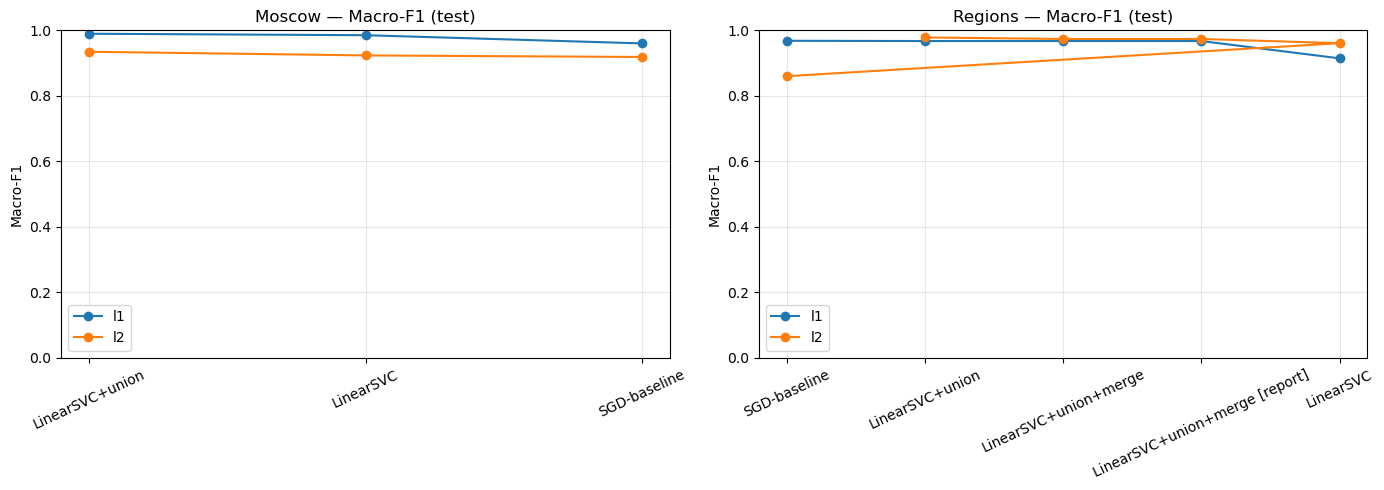

In [28]:
# Visualization: Macro-F1 across experiments
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, dataset in zip(axes, ['Moscow', 'Regions']):
    sub = results_df[results_df['dataset'] == dataset]
    for label, group in sub.groupby('label'):
        ax.plot(group['experiment'], group['macro_f1'], marker='o', label=label)
    ax.set_title(f'{dataset} — Macro-F1 (test)')
    ax.set_ylabel('Macro-F1')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=25)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()